In [1508]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [1509]:
df = pd.read_csv('datasets/train.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [1510]:
df.shape

(891, 3)

In [1511]:
df.dropna(inplace=True)

In [1512]:
df.shape

(714, 3)

In [1513]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [1514]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [1515]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [1516]:
clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test,y_pred)

0.6293706293706294

In [1517]:
np.mean(cross_val_score(clf, X, y, cv = 10, scoring='accuracy'))

np.float64(0.630281690140845)

In [1533]:
kbin_age = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile', quantile_method='averaged_inverted_cdf')
kbin_fare = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile', quantile_method='averaged_inverted_cdf')

In [1534]:
trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1])
])

In [1535]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [1536]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [1537]:

{'first': KBinsDiscretizer(encode='ordinal', n_bins=10),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=10)}

{'first': KBinsDiscretizer(encode='ordinal', n_bins=10),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=10)}

In [1538]:

clf = DecisionTreeClassifier()
clf.fit(X_train_trf, y_train)
y_pred2 = clf.predict(X_test_trf)

In [1539]:
accuracy_score(y_test, y_pred2)

0.6363636363636364

In [1546]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(), X_trf, y, scoring='accuracy'))

np.float64(0.64574017531764)

In [1566]:
def discretize(bins,strategy):
    
    kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy, quantile_method='averaged_inverted_cdf')
    kbin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy, quantile_method='averaged_inverted_cdf')

    trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(14,5))

    sns.histplot(X['Age'], kde=True, ax=axes[0,0])
    axes[0,0].set_title("Before")

    sns.histplot(X_trf[:, 0], kde=True, ax=axes[0,1])
    axes[0,1].set_title("After")

    sns.histplot(X['Fare'], kde=True, ax=axes[1,0])
    axes[1,0].set_title("Before")

    sns.histplot(X_trf[:, 1], kde=True, ax=axes[1,1])
    axes[1,1].set_title("After")

    plt.show()


    

0.6344679186228482


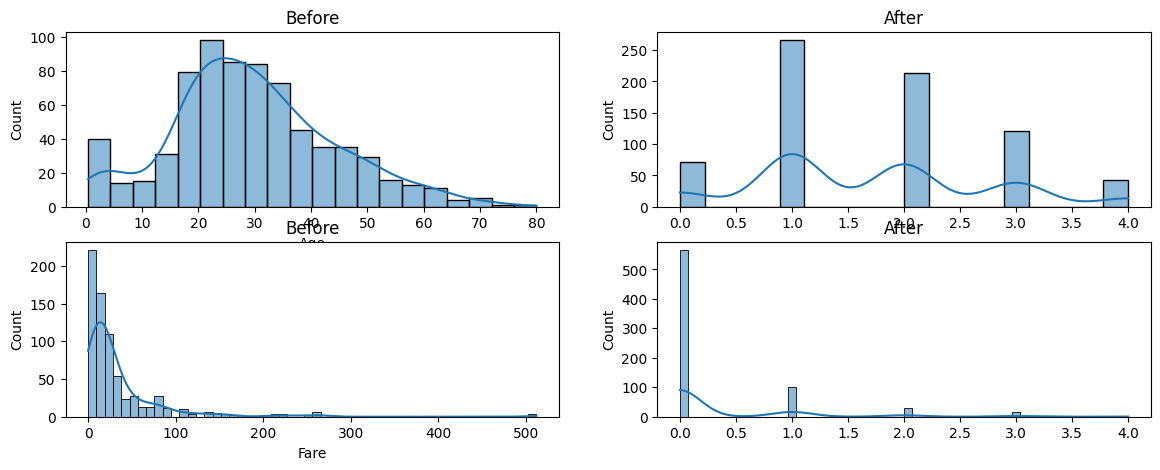

In [1570]:
discretize(5, 'kmeans')